<a href="https://colab.research.google.com/github/shijithpulikkal/Exploratory-Data-Analysis/blob/main/13_online_retail_rfm_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import timedelta

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [2]:
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/My Drive/Colab Notebooks/EDA/online_retail_II.csv', encoding='ISO-8859-1')

df.head()

Mounted at /content/drive


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [3]:
df.shape

(1067371, 8)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  object 
 1   StockCode    1067371 non-null  object 
 2   Description  1062989 non-null  object 
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  object 
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 65.1+ MB


In [5]:
df.describe()

,Quantity,Price,Customer ID
count,1.067371e+06,1.067371e+06,824364.000000
mean,9.938898e+00,4.649388e+00,15324.638504
std,1.727058e+02,1.235531e+02,1697.464450
min,-8.099500e+04,-5.359436e+04,12346.000000
25%,1.000000e+00,1.250000e+00,13975.000000
50%,3.000000e+00,2.100000e+00,15255.000000
75%,1.000000e+01,4.150000e+00,16797.000000
max,8.099500e+04,3.897000e+04,18287.000000


**2. Data Cleaning**

In [6]:
# Check missing values
df.isnull().sum().sort_values(ascending=False)

,0
Customer ID,243007
Description,4382
StockCode,0
Invoice,0
Quantity,0
InvoiceDate,0
Price,0
Country,0


In [7]:
# Drop rows with missing CustomerID - can't segment unidentified customers
df = df.dropna(subset=['Customer ID'])
df.shape

(824364, 8)

In [8]:
# Check invoice numbers - cancellations are prefixed with 'C'
df['Invoice'] = df['Invoice'].astype(str)
cancelled = df['Invoice'].str.startswith('C')
print(f"Cancelled orders: {cancelled.sum()}")

df = df[~cancelled]
df.shape

Cancelled orders: 18744


(805620, 8)

In [9]:
# Remove negative/zero Quantity or Price (returns, errors)
print("Negative/zero Quantity:", (df['Quantity'] <= 0).sum())
print("Negative/zero Price:", (df['Price'] <= 0).sum())

df = df[(df['Quantity'] > 0) & (df['Price'] > 0)]
df.shape

Negative/zero Quantity: 0
Negative/zero Price: 71


(805549, 8)

In [10]:
# Create TotalPrice
df['TotalPrice'] = df['Quantity'] * df['Price']

# Convert InvoiceDate to datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

df[['Quantity', 'Price', 'TotalPrice', 'InvoiceDate']].head()

,Quantity,Price,TotalPrice,InvoiceDate
0,12,6.95,83.4,2009-12-01 07:45:00
1,12,6.75,81.0,2009-12-01 07:45:00
2,12,6.75,81.0,2009-12-01 07:45:00
3,48,2.10,100.8,2009-12-01 07:45:00
4,24,1.25,30.0,2009-12-01 07:45:00


In [11]:
# Check duplicates
df = df.drop_duplicates()
df.shape

(779425, 9)

In [12]:
df['Customer ID'] = df['Customer ID'].astype(int)

**3. Univariate Analysis**

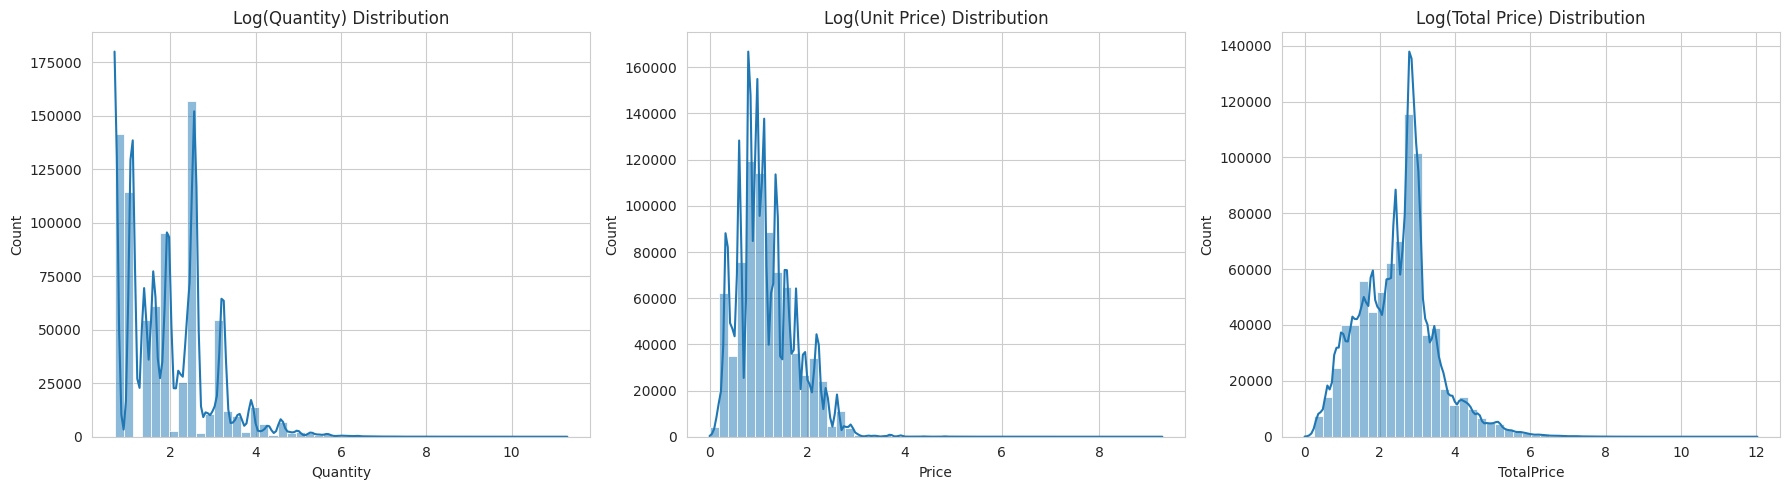

In [13]:
# Quantity, Price, TotalPrice distributions (log-transformed due to skew)
fig, axes = plt.subplots(1, 3, figsize=(18,5))

sns.histplot(np.log1p(df['Quantity']), bins=50, kde=True, ax=axes[0])
axes[0].set_title('Log(Quantity) Distribution')

sns.histplot(np.log1p(df['Price']), bins=50, kde=True, ax=axes[1])
axes[1].set_title('Log(Unit Price) Distribution')

sns.histplot(np.log1p(df['TotalPrice']), bins=50, kde=True, ax=axes[2])
axes[2].set_title('Log(Total Price) Distribution')

plt.tight_layout()
plt.show()

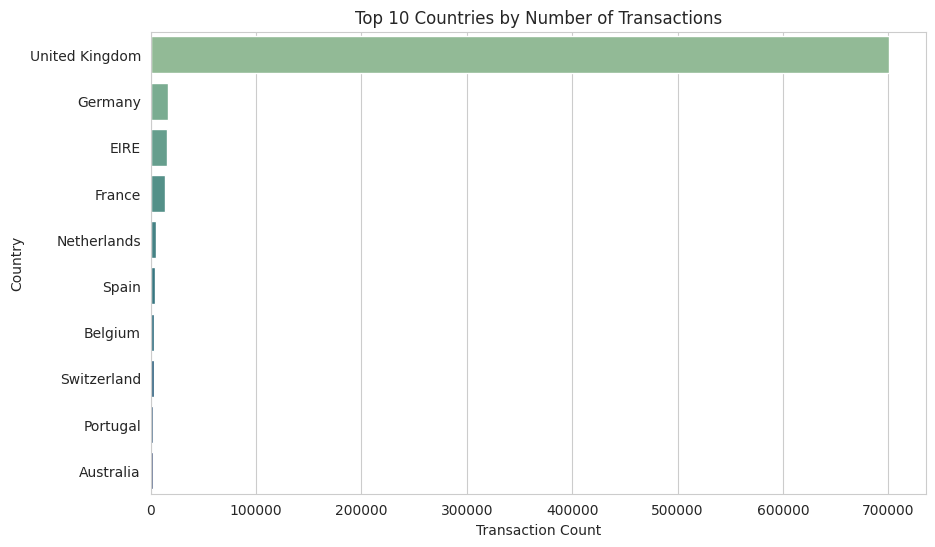

In [14]:
# Orders by country - top 10
top_countries = df['Country'].value_counts().head(10)

sns.barplot(x=top_countries.values, y=top_countries.index, hue=top_countries.index, palette='crest', legend=False)
plt.title('Top 10 Countries by Number of Transactions')
plt.xlabel('Transaction Count')
plt.show()

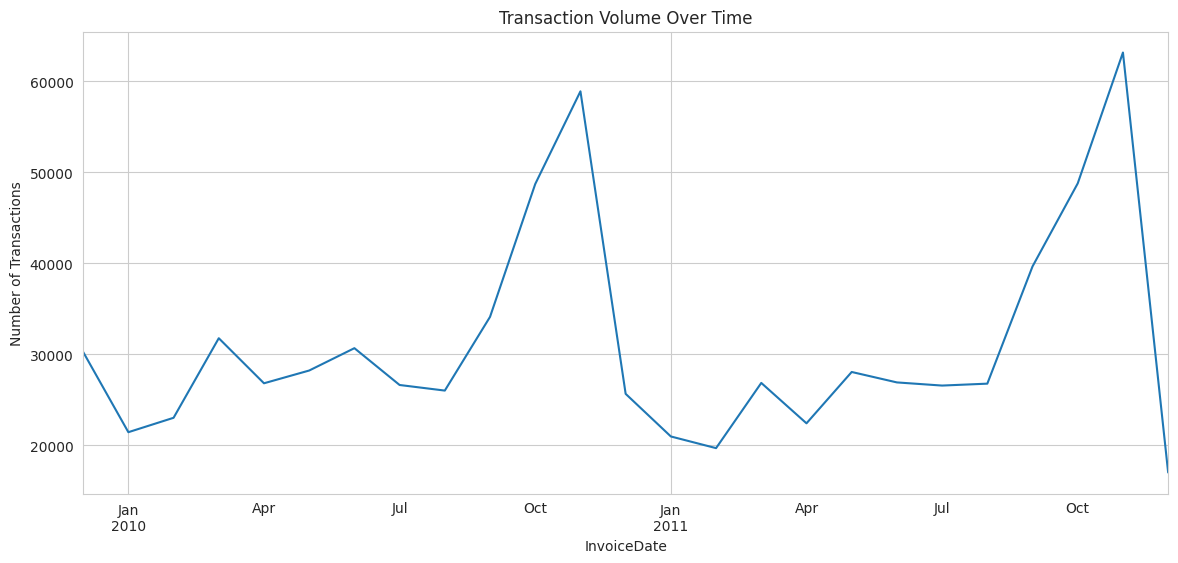

In [15]:
# Orders over time
orders_over_time = df.set_index('InvoiceDate').resample('ME').size()

plt.figure(figsize=(14,6))
orders_over_time.plot()
plt.title('Transaction Volume Over Time')
plt.ylabel('Number of Transactions')
plt.show()

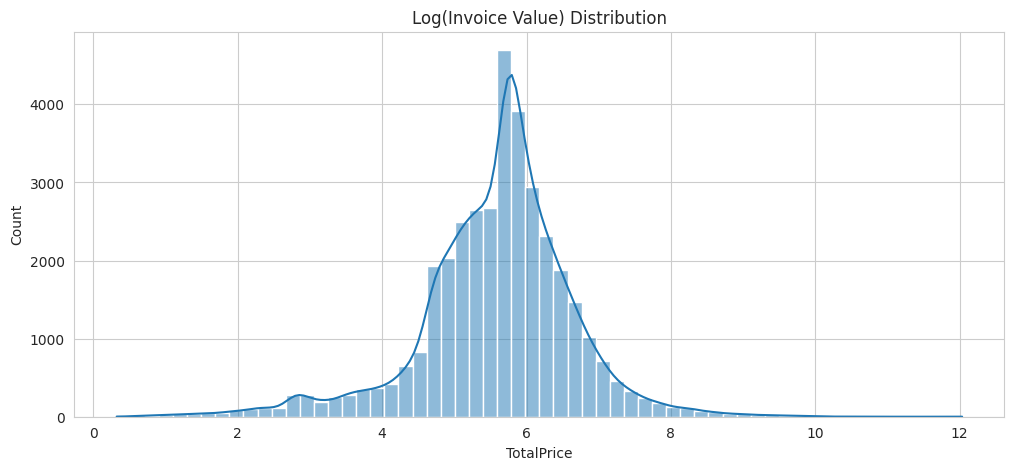

In [16]:
# Order value per invoice distribution
invoice_value = df.groupby('Invoice')['TotalPrice'].sum()

plt.figure(figsize=(12,5))
sns.histplot(np.log1p(invoice_value), bins=60, kde=True)
plt.title('Log(Invoice Value) Distribution')
plt.show()

**4. RFM Analysis**

In [17]:
# Set analysis date as one day after the last transaction in the dataset
analysis_date = df['InvoiceDate'].max() + timedelta(days=1)
print("Analysis date:", analysis_date)

rfm = df.groupby('Customer ID').agg(
    Recency=('InvoiceDate', lambda x: (analysis_date - x.max()).days),
    Frequency=('Invoice', 'nunique'),
    Monetary=('TotalPrice', 'sum')
).reset_index()

rfm.head()

Analysis date: 2011-12-10 12:50:00


,Customer ID,Recency,Frequency,Monetary
0,12346,326,12,77556.46
1,12347,2,8,4921.53
2,12348,75,5,2019.40
3,12349,19,4,4428.69
4,12350,310,1,334.40


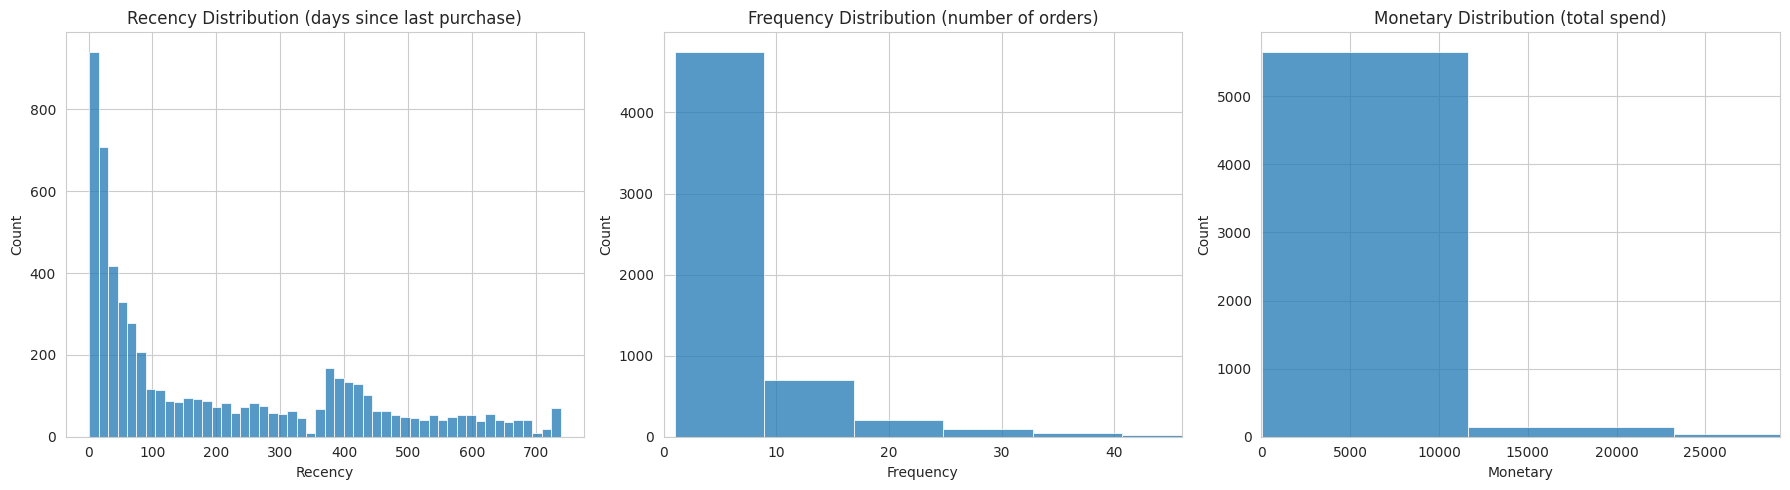

In [18]:
# Distribution of each RFM metric
fig, axes = plt.subplots(1, 3, figsize=(18,5))

sns.histplot(rfm['Recency'], bins=50, ax=axes[0])
axes[0].set_title('Recency Distribution (days since last purchase)')

sns.histplot(rfm['Frequency'], bins=50, ax=axes[1])
axes[1].set_title('Frequency Distribution (number of orders)')
axes[1].set_xlim(0, rfm['Frequency'].quantile(0.99))

sns.histplot(rfm['Monetary'], bins=50, ax=axes[2])
axes[2].set_title('Monetary Distribution (total spend)')
axes[2].set_xlim(0, rfm['Monetary'].quantile(0.99))

plt.tight_layout()
plt.show()

In [19]:
# Quartile-based RFM scoring (1-4, 4 = best)
rfm['R_score'] = pd.qcut(rfm['Recency'], 4, labels=[4,3,2,1]).astype(int)
rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 4, labels=[1,2,3,4]).astype(int)
rfm['M_score'] = pd.qcut(rfm['Monetary'], 4, labels=[1,2,3,4]).astype(int)

rfm['RFM_Score'] = rfm['R_score'] + rfm['F_score'] + rfm['M_score']
rfm.head()

,Customer ID,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score
0,12346,326,12,77556.46,2,4,4,10
1,12347,2,8,4921.53,4,4,4,12
2,12348,75,5,2019.40,3,3,3,9
3,12349,19,4,4428.69,4,3,4,11
4,12350,310,1,334.40,2,1,1,4


In [20]:
# Segment customers using simple rules based on RFM score
def segment_customer(row):
    if row['RFM_Score'] >= 10:
        return 'Champions'
    elif row['RFM_Score'] >= 8:
        return 'Loyal Customers'
    elif row['RFM_Score'] >= 6:
        return 'Potential Loyalists'
    elif row['R_score'] <= 2 and row['F_score'] <= 2:
        return 'At Risk'
    else:
        return 'Others'

rfm['Segment'] = rfm.apply(segment_customer, axis=1)
rfm['Segment'].value_counts()

,count
Segment,
Champions,1740
At Risk,1591
Potential Loyalists,1216
Loyal Customers,1186
Others,145


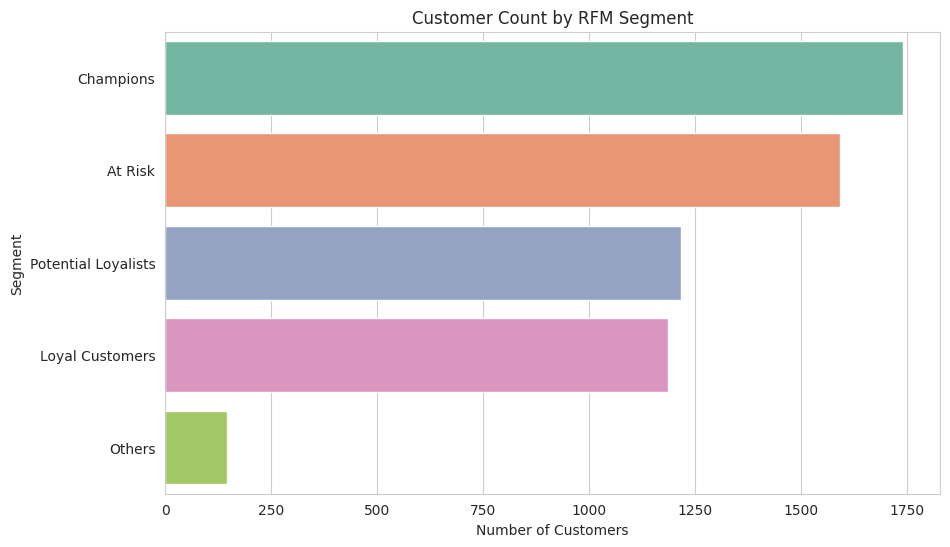

In [21]:
# Visualize segment sizes
segment_counts = rfm['Segment'].value_counts()

plt.figure(figsize=(10,6))
sns.barplot(x=segment_counts.values, y=segment_counts.index, hue=segment_counts.index, palette='Set2', legend=False)
plt.title('Customer Count by RFM Segment')
plt.xlabel('Number of Customers')
plt.show()

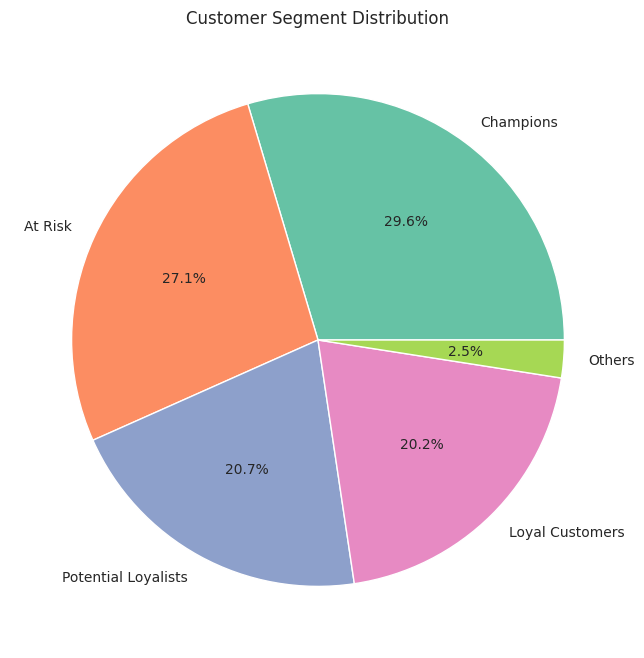

In [22]:
# Pie chart view - often used in RFM presentations
plt.figure(figsize=(8,8))
plt.pie(segment_counts.values, labels=segment_counts.index, autopct='%1.1f%%', colors=sns.color_palette('Set2'))
plt.title('Customer Segment Distribution')
plt.show()

**5. Multivariate Analysis**

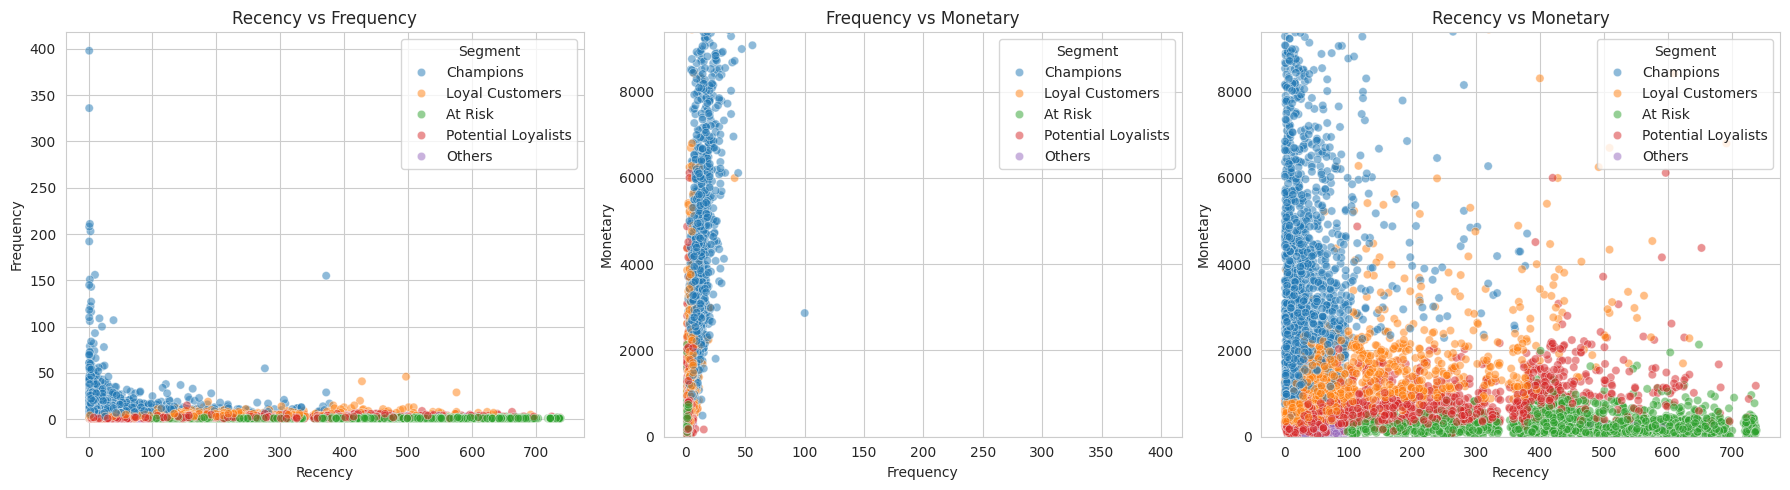

In [23]:
# Pairwise RFM relationships
fig, axes = plt.subplots(1, 3, figsize=(18,5))

sns.scatterplot(data=rfm, x='Recency', y='Frequency', hue='Segment', alpha=0.5, ax=axes[0])
axes[0].set_title('Recency vs Frequency')

sns.scatterplot(data=rfm, x='Frequency', y='Monetary', hue='Segment', alpha=0.5, ax=axes[1])
axes[1].set_ylim(0, rfm['Monetary'].quantile(0.95))
axes[1].set_title('Frequency vs Monetary')

sns.scatterplot(data=rfm, x='Recency', y='Monetary', hue='Segment', alpha=0.5, ax=axes[2])
axes[2].set_ylim(0, rfm['Monetary'].quantile(0.95))
axes[2].set_title('Recency vs Monetary')

plt.tight_layout()
plt.show()

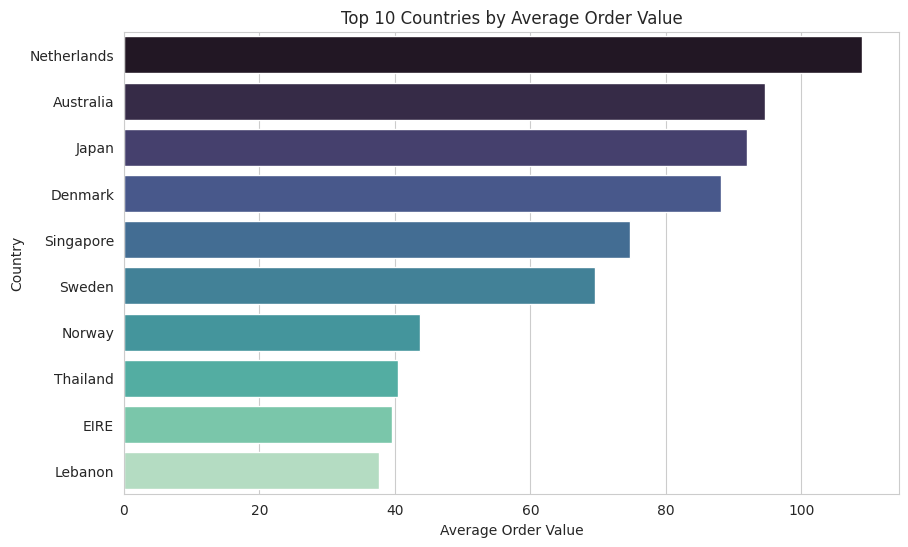

In [24]:
# Average order value by country - top 10
country_aov = df.groupby('Country')['TotalPrice'].mean().sort_values(ascending=False).head(10)

sns.barplot(x=country_aov.values, y=country_aov.index, hue=country_aov.index, palette='mako', legend=False)
plt.title('Top 10 Countries by Average Order Value')
plt.xlabel('Average Order Value')
plt.show()

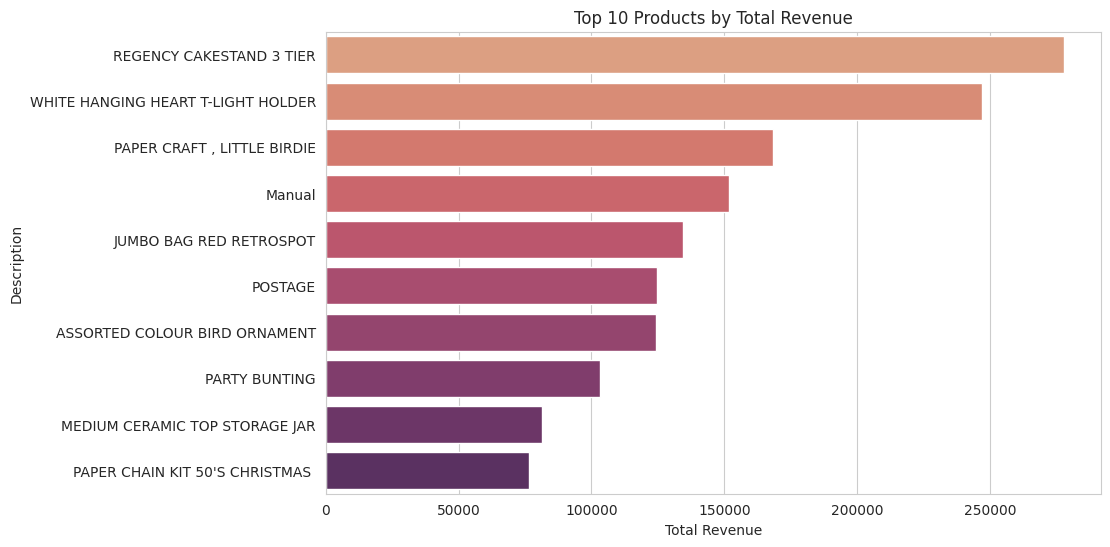

In [25]:
# Top 10 products by total revenue
top_products = df.groupby('Description')['TotalPrice'].sum().sort_values(ascending=False).head(10)

sns.barplot(x=top_products.values, y=top_products.index, hue=top_products.index, palette='flare', legend=False)
plt.title('Top 10 Products by Total Revenue')
plt.xlabel('Total Revenue')
plt.show()

In [26]:
# Top 10 customers by total spend
top_customers = rfm.sort_values('Monetary', ascending=False).head(10)[['Customer ID', 'Monetary', 'Frequency', 'Segment']]
top_customers

,Customer ID,Monetary,Frequency,Segment
5692,18102,580987.04,145,Champions
2277,14646,528602.52,151,Champions
1789,14156,313437.62,156,Champions
2538,14911,291420.81,398,Champions
5050,17450,244784.25,51,Champions
1331,13694,195640.69,143,Champions
5109,17511,172132.87,60,Champions
4061,16446,168472.50,2,Champions
4295,16684,147142.77,55,Champions
68,12415,144458.37,28,Champions


**6. Insights Summary**

## Key Insights

- "Champions" make up [X]% of customers but likely contribute a disproportionate share of total revenue — worth prioritizing for retention.
- "At Risk" customers ([Y]% of the base) haven't purchased recently despite previously being active — a natural win-back campaign target.
- The majority of customers fall into "Others" or "Potential Loyalists," suggesting room to nurture mid-tier customers into loyal ones.
- [Country] dominates transaction volume, consistent with this being a UK-based retailer, but [Country] shows a higher average order value — worth investigating for premium-market potential.
- The top 10 products by revenue are dominated by [describe pattern, e.g., seasonal/decorative items] — useful for inventory and marketing focus.
- Recency and Frequency show [an inverse/some] relationship — customers who buy more often also tend to have purchased more recently, as expected.
- [Add 1-2 more insights specific to what you observed]

## What This Enables

- **Champions:** reward with loyalty perks or early access to new products to maintain engagement.
- **At Risk:** targeted win-back email campaigns or limited-time discounts.
- **Potential Loyalists:** nurture campaigns to increase purchase frequency.
- This RFM segmentation could feed directly into a clustering model (e.g., K-Means) for a more data-driven segmentation as a natural next step beyond rule-based tiers.